In [1]:
#05-Jun-26, Noor Natour
#Import computational functions used in the analysis.
from computational_routines import *
import matplotlib
import scipy
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gmean
import sys
import seaborn as sns

In [2]:
#Print Python and package versions used in the analysis.

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("SciPy:", scipy.__version__)
print("Seaborn", sns.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
SciPy: 1.16.3
Seaborn 0.13.2


In [3]:
#Load variables probabilities and observed neuron counts from csv files.
df_variables = pd.read_csv("observed_neurons.csv")

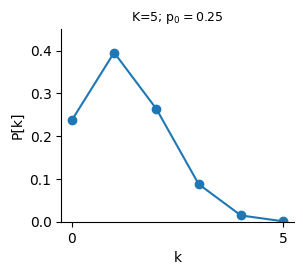

In [4]:
#05-Jun-26
#Plot probability distribution for K=5 variables with equal prevalence p0=0.25 (Fig. 4a)
#Calls: probability_k_variables()

K=5
p0=0.25
n_neurons=1
probs_dict={f"v{i}": p0 for i in range(1, K + 1)}

k_values = []
probabilities = []

for k in range(K + 1):
    probability, expected = probability_k_variables(k, probs_dict, n_neurons)
    k_values.append(k)
    probabilities.append(probability)

plt.figure(figsize=(3, 2.5))
plt.plot(k_values, probabilities, marker='o')
plt.xlabel("k")
plt.ylabel("P[k]")
plt.title(r"K=5; $\mathrm{p}_0=0.25$", fontsize=9)
plt.xticks(np.arange(0, 6, step=5))
plt.ylim(0, 0.45)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("K5_p025_distribution.pdf", bbox_inches="tight")
plt.show()

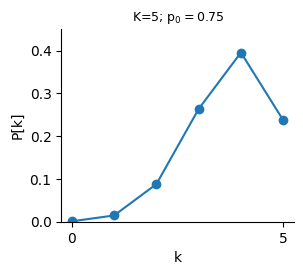

In [5]:
#05-Jun-26
#Plot probability distribution for K=5 variables with equal prevalence p0=0.75 (Fig. 4b)
#Calls: probability_k_variables()

K=5
p0=0.75
n_neurons=1
probs_dict={f"v{i}": p0 for i in range(1, K + 1)}

k_values = []
probabilities = []

for k in range(K + 1):
    probability, expected = probability_k_variables(k, probs_dict, n_neurons)
    k_values.append(k)
    probabilities.append(probability)

plt.figure(figsize=(3, 2.5))
plt.plot(k_values, probabilities, marker='o')

plt.xlabel("k")
plt.ylabel("P[k]")
plt.title(r"K=5; $\mathrm{p}_0=0.75$", fontsize=9)
plt.xticks(np.arange(0, 6, step=5))
plt.ylim(0, 0.45)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("K5_p075_distribution.pdf", bbox_inches="tight")
plt.show()

In [6]:
#05-Jun-26
#Heatmap data generation
#Calculates P(k|p₀) for k = 0,...,K across a range of prevalence values.
#Stores the resulting probability distributions in a matrix for heatmap visualization assuming independent encoding.
#Calls: probability_k_variables()

p_values = np.arange(0, 1.01, 0.01)

heatmap_data = []

for p0 in p_values:
    probs_dict = {f"v{i}": p0 for i in range(1, K + 1)}

    probabilities = []
    for k in range(K + 1):
        probability, expected = probability_k_variables(k, probs_dict, n_neurons=1)
        probabilities.append(probability)

    heatmap_data.append(probabilities)

heatmap_data = np.array(heatmap_data).T

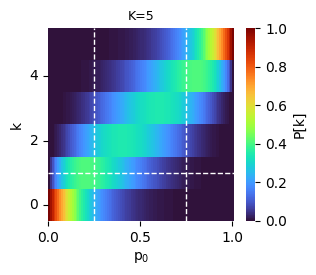

In [7]:
#05-Jun-26
#Heatmap visualization (Fig. 4c)
#Displays P(k|p₀) as a heatmap for K variables.

plt.figure(figsize=(3, 2.5))

ax=sns.heatmap(heatmap_data, cmap="turbo", cbar_kws={'label':'P[k]'})
x1 = np.argmin(np.abs(p_values - 0.25))
x2 = np.argmin(np.abs(p_values - 0.75))

ax.axvline(x=x1, color='white', linestyle='--', linewidth=1)
ax.axvline(x=x2, color='white', linestyle='--', linewidth=1)
ax.axhline(y=1.5, color='white', linestyle='--', linewidth=1)

plt.gca().invert_yaxis()
plt.xlabel(r"$\mathrm{p}_0$")
plt.ylabel("k")
plt.title("K=5", fontsize=9)

plt.xticks(ticks=np.linspace(0, len(p_values)-1, 3), labels=[f"{x:.1f}" for x in np.linspace(0, 1, 3)], rotation=0)
plt.yticks([0.5, 2.5, 4.5], labels=[0, 2, 4], rotation=0)
plt.savefig("K5_heatmap.pdf", bbox_inches="tight")
plt.show()

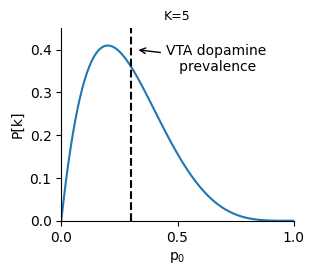

In [49]:
#05-Jun-26
#Plot P(k=1) as a function of prevalence p0 for K=5 (Fig. 4d).
#Mark the prevalence that maximizes P(k=1).
#Calls: probability_k_variables(), peak_properties()

pk1_values = heatmap_data[1, :]
variable_prevalences = df_variables["count"] / df_variables["total"]
mean_prevalence = gmean(variable_prevalences)
plt.figure(figsize=(3, 2.5))

plt.plot(p_values, pk1_values)
plt.axvline(x=mean_prevalence, linestyle='--', color='black')

plt.xlabel(r"$\mathrm{p}_0$")
plt.ylabel("P[k]")
plt.title("K=5", fontsize=9)

plt.ylim(0, 0.45)
plt.xlim(0, 1)
plt.xticks([0, 0.5, 1])
plt.annotate("VTA dopamine\n   prevalence", xy=(0.32, 0.4), xytext=(0.45, 0.35), arrowprops=dict(arrowstyle="->"))

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("K5_pk_curve.pdf", bbox_inches="tight")
plt.show()

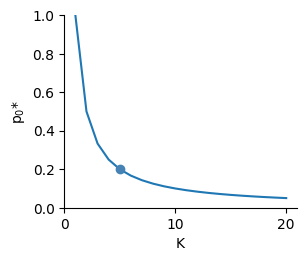

In [ ]:
#05-Jun-26
#Plot the prevalence that maximizes P(k=1) as a function of the number of variables K (Fig. 4e).
#Calls: peak_properties()

K_values = np.arange(1, 21)

for K in K_values:
    _ , peak_probability = peak_properties(k)

p0_max_values = []
for K in K_values:
    p0_max, max_probability = peak_properties(K)
    p0_max_values.append(p0_max)

plt.figure(figsize=(3, 2.5))

plt.plot(K_values, p0_max_values)
plt.plot(5, p0_max_values[4], marker='o', color='steelblue')
plt.xlabel("K")
plt.ylabel(r"$\mathrm{p}_0$*")
plt.ylim(0, 1)
plt.xticks(np.arange(0, 21, step=10))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("p0_max_vs_K.pdf", bbox_inches="tight")
plt.show()

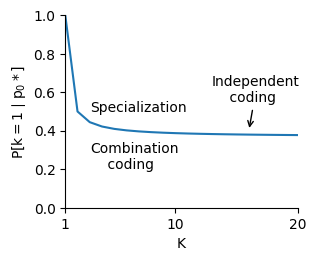

In [ ]:
#05-Jun-26
#Peak probability analysis
#Calls: peak_properties()
#Plots the maximal probability of observing neurons encoding exactly one variable as a function of the
#number of encoded variables K (Fig. 4f)
#Illustrates the transition between specialization, combination coding, and the independence limit.

max_probabilities = []

for K in K_values:
    p0_max, max_probability = peak_properties(K)
    max_probabilities.append(max_probability)
plt.figure(figsize=(3,2.5))

plt.plot(K_values, max_probabilities)
plt.xlabel("K")
plt.ylabel(r"$\mathregular{P[k=1 \mid p_0*]}$")

plt.xlim(1, 20)
plt.xticks([1 , 10, 20])
plt.ylim(0,1)

plt.text(3, 0.5, "Specialization")
plt.text(3, 0.2, "Combination\n    coding")

plt.annotate("Independent\n    coding", xy=(16, 0.4), xytext=(13, 0.55), arrowprops=dict(arrowstyle="->"))

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)



plt.savefig("specialization_limit.pdf", bbox_inches="tight")

plt.show()